<a href="https://colab.research.google.com/github/Akshatha7710/RAG-based-Document-Question-Answering-System-using-LangChain-FAISS-and-LLMs/blob/main/Question%20Answering%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG-Based Document Question Answering System
**Stack:** PyMuPDF · python-docx · ChromaDB · Sentence-Transformers · Gemini 2.5 Flash (google-genai SDK)

| Feature | Status |
|---|---|
| Multi-format ingestion (.pdf .docx .txt .md .html) | ✅ |
| Google Drive persistence | ✅ |
| Multi-query expansion | ✅ |
| Keyword search fallback | ✅ |
| Translate answer to any language | ✅ |
| Export chat history to .txt | ✅ |
| ROUGE-L + BLEU-1 + Semantic eval | ✅ |
| Radar chart + HTML report + CSV export | ✅ |

In [6]:
# Cell 1: Install Dependencies
import subprocess, sys

_PACKAGES = [
    'pymupdf',
    'python-docx',
    'chromadb',
    'sentence-transformers',
    'langchain-text-splitters',
    'google-genai',
    'tqdm',
    'nltk',
    'matplotlib',
    'rouge-score',
    'beautifulsoup4',
]

print('Installing packages...')
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + _PACKAGES,
    capture_output=True, text=True
)
if result.returncode != 0:
    print('pip stderr:', result.stderr[-1000:])
    raise RuntimeError('pip install failed')

# Verify the packages most commonly missing / mismatched
for pkg, mod in [('pymupdf', 'fitz'), ('python-docx', 'docx'),
                  ('rouge-score', 'rouge_score'), ('google-genai', 'google.genai')]:
    try:
        __import__(mod)
        print(f'{pkg} OK')
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', pkg])
        print(f'{pkg} force-reinstalled')

print('\nAll packages ready. Proceed to Cell 2.')


Installing packages...
pymupdf OK
python-docx OK
rouge-score OK
google-genai OK

All packages ready. Proceed to Cell 2.


In [7]:
# Cell 2: Set API Key
import os

try:
    from google.colab import userdata
    api_key = userdata.get('GEMINI_API_KEY')
except ImportError:
    api_key = os.environ.get('GEMINI_API_KEY', '')

if not api_key or len(api_key) < 10:
    raise ValueError(
        'GEMINI_API_KEY secret is missing or invalid.\n'
        'Add it via Colab Secrets (🔑 icon in the left sidebar).'
    )

os.environ['GEMINI_API_KEY'] = api_key
print('API Key loaded:', api_key[:10], '...')

API Key loaded: AIzaSyDFX_ ...


In [9]:
# Cell 3: Imports & Setup
import fitz
import docx
import chromadb
from google import genai
from google.genai import types
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
import time, os, threading, re

# ── Central configuration ─────────────────────────────────────────
CONFIG = {
    'model':               'gemini-2.5-flash',
    'embedder':            'all-MiniLM-L6-v2',
    'chunk_size':          500,
    'chunk_overlap':       100,
    'top_k':               5,
    'relevance_threshold': 0.35,
    'db_path':             '/content/chroma_db',
    'max_retries':         5,
    'rpm_limit':           10,
    'use_drive':           True,
    'multi_query':         True,
}

# ── Optional: mount Google Drive for persistence ──────────────────
if CONFIG['use_drive']:
    try:
        from google.colab import drive as _drive
        _drive.mount('/content/drive', force_remount=False)
        CONFIG['db_path'] = '/content/drive/MyDrive/rag_chroma_db'
        print('Google Drive mounted — DB will persist across sessions.')
    except Exception as _e:
        print(f'Drive mount skipped ({_e}) — using /content/chroma_db')

# ── Gemini client (google-genai unified SDK) ───────────────────────
gemini_client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

# ── Embedding model ───────────────────────────────────────────────
embedder = SentenceTransformer(CONFIG['embedder'])

# ── Persistent vector store ───────────────────────────────────────
chroma     = chromadb.PersistentClient(path=CONFIG['db_path'])
collection = chroma.get_or_create_collection(
    'docs', metadata={'hnsw:space': 'cosine'}
)

# ── Text splitter ─────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG['chunk_size'],
    chunk_overlap=CONFIG['chunk_overlap'],
)

# ── Thread-safe rate limiter ──────────────────────────────────────
class RateLimiter:
    def __init__(self, rpm: int) -> None:
        self.interval = 60.0 / rpm
        self._lock    = threading.Lock()
        self._last    = 0.0
    def wait(self) -> None:
        with self._lock:
            gap = self.interval - (time.monotonic() - self._last)
            if gap > 0:
                time.sleep(gap)
            self._last = time.monotonic()

_rate_limiter = RateLimiter(CONFIG['rpm_limit'])

print(f'All components initialized')
print(f'Model         : {CONFIG["model"]}')
print(f'Vector DB path : {CONFIG["db_path"]}')
print(f'Chunks in DB   : {collection.count()}')


Drive mount skipped (Error: credential propagation was unsuccessful) — using /content/chroma_db


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

All components initialized
Model         : gemini-2.5-flash
Vector DB path : /content/chroma_db
Chunks in DB   : 0


In [10]:
# Cell 4: Core Functions

# ── Gemini call with exponential backoff ─────────────────────────
def call_gemini(prompt: str, stream: bool = True,
                max_attempts: int = CONFIG['max_retries']) -> str:
    for attempt in range(max_attempts):
        try:
            _rate_limiter.wait()
            if stream:
                parts: list[str] = []
                for chunk in gemini_client.models.generate_content_stream(
                    model=CONFIG['model'], contents=prompt
                ):
                    text = chunk.text or ''
                    print(text, end='', flush=True)
                    parts.append(text)
                print()
                return ''.join(parts)
            response = gemini_client.models.generate_content(
                model=CONFIG['model'], contents=prompt
            )
            return response.text or ''
        except Exception as e:
            if attempt == max_attempts - 1:
                return f'Failed after {max_attempts} attempts: {e}'
            wait_secs = 2 ** attempt * 5
            print(f'Attempt {attempt+1} failed — retrying in {wait_secs}s… ({e})')
            time.sleep(wait_secs)
    return ''


# ── Strip ```json / ``` code fences safely (str.lstrip/rstrip is char-set
#    based and corrupts text — this does a proper prefix/suffix removal) ──
def _strip_code_fence(raw: str) -> str:
    text = raw.strip()
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text.strip()


def json_safe_load(raw: str):
    import json
    try:
        return json.loads(raw)
    except Exception:
        return None


# ── Text extraction ───────────────────────────────────────────────
_SUPPORTED = {'.pdf', '.docx', '.txt', '.md', '.html', '.htm'}

def extract_text(path: str) -> str:
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File not found: '{path}'")
    ext = os.path.splitext(path)[1].lower()
    if ext == '.pdf':
        with fitz.open(path) as doc:
            return '\n\n'.join(p.get_text() for p in doc)
    if ext == '.docx':
        d = docx.Document(path)
        return '\n\n'.join(p.text for p in d.paragraphs if p.text.strip())
    if ext in ('.txt', '.md'):
        with open(path, encoding='utf-8', errors='replace') as f:
            return f.read()
    if ext in ('.html', '.htm'):
        try:
            from bs4 import BeautifulSoup
            with open(path, encoding='utf-8', errors='replace') as f:
                return BeautifulSoup(f, 'html.parser').get_text('\n', strip=True)
        except ImportError:
            with open(path, encoding='utf-8', errors='replace') as f:
                return re.sub(r'<[^>]+>', ' ', f.read())
    raise ValueError(f"Unsupported type '{ext}'. Supported: {sorted(_SUPPORTED)}")


# ── Ingestion ─────────────────────────────────────────────────────
def ingest_file(path: str) -> None:
    name = os.path.basename(path)
    try:
        text = extract_text(path)
    except (ValueError, FileNotFoundError) as e:
        print(f'Skipping {name}: {e}'); return
    if not text.strip():
        print(f'{name} is empty — skipping.'); return
    chunks    = splitter.split_text(text)
    if not chunks:
        print(f'{name} produced no chunks — skipping.'); return
    embs      = embedder.encode(chunks, show_progress_bar=True).tolist()
    ids       = [f'{name}_chunk_{i}' for i in range(len(chunks))]
    metas     = [{'source': name, 'chunk_index': i, 'text_lower': c.lower()}
                 for i, c in enumerate(chunks)]
    collection.upsert(ids=ids, embeddings=embs, documents=chunks, metadatas=metas)
    print(f'Ingested {len(chunks)} chunks from "{name}"')

def ingest_multiple_files(paths: list[str]) -> None:
    for p in tqdm(paths, desc='Ingesting'):
        ingest_file(p)
    print(f'\n📚 Total chunks in DB: {collection.count()}')

# aliases
ingest_pdf = ingest_file
ingest_multiple_pdfs = ingest_multiple_files


# ── Delete / clear ────────────────────────────────────────────────
def delete_source(filename: str) -> None:
    ids = collection.get(where={'source': filename}, include=['metadatas'])['ids']
    if not ids:
        print(f'No chunks found for "{filename}"'); return
    collection.delete(ids=ids)
    print(f'Deleted {len(ids)} chunks from "{filename}"')

def clear_collection(confirm: bool = False) -> None:
    if not confirm:
        print('Pass confirm=True to clear everything.'); return
    ids = collection.get()['ids']
    if not ids:
        print('Collection is already empty.'); return
    collection.delete(ids=ids)
    print(f'Cleared {len(ids)} chunks.')


# ── List / guard ──────────────────────────────────────────────────
def list_sources() -> None:
    total = collection.count()
    if total == 0:
        print('Vector store is empty. Run Cell 5 first.'); return
    metas = collection.get(include=['metadatas'])['metadatas']
    counts: dict[str, int] = {}
    for m in metas:
        counts[m.get('source', '?')] = counts.get(m.get('source', '?'), 0) + 1
    print(f'{total} chunks from {len(counts)} file(s):')
    for src, n in sorted(counts.items()):
        print(f'   • {src}  ({n} chunks)')

def _require_documents() -> None:
    if collection.count() == 0:
        raise RuntimeError('No documents ingested. Run Cell 5 first.')


# ── Multi-query expansion ─────────────────────────────────────────
def _expand_query(question: str) -> list[str]:
    """
    Generate 3 rephrasings of the question to improve retrieval coverage.
    Falls back to the original question if Gemini call fails.
    """
    if not CONFIG['multi_query']:
        return [question]
    prompt = (
        'Rephrase the following question in 3 different ways to improve '
        'document retrieval. Return ONLY a JSON array of 3 strings, '
        'no preamble or markdown.\n\n'
        f'Question: {question}'
    )
    try:
        raw = call_gemini(prompt, stream=False)
        variants = json_safe_load(_strip_code_fence(raw))
        if isinstance(variants, list) and variants:
            return [question] + [str(v) for v in variants[:3]]
    except Exception:
        pass
    return [question]


# ── Hybrid retrieval (semantic + keyword fallback) ────────────────
def _retrieve(question: str, top_k: int):
    """
    1. Expand question into multiple queries (if enabled).
    2. Run semantic search for each query, merge + deduplicate.
    3. If no results pass threshold, fall back to keyword search.
    Returns (context_str, chunks, scores, metadatas).
    """
    queries  = _expand_query(question)
    seen_ids : set[str] = set()
    combined : list[tuple[str, float, dict]] = []

    for q in queries:
        q_emb   = embedder.encode([q]).tolist()
        results = collection.query(
            query_embeddings=q_emb,
            n_results=top_k,
            include=['documents', 'distances', 'metadatas'],
        )
        for chunk, dist, meta in zip(
            results['documents'][0],
            results['distances'][0],
            results['metadatas'][0],
        ):
            uid = f"{meta.get('source')}_{meta.get('chunk_index')}"
            if uid not in seen_ids:
                seen_ids.add(uid)
                combined.append((chunk, dist, meta))

    # Sort by distance (lowest = most relevant) and apply threshold
    combined.sort(key=lambda x: x[1])
    threshold = CONFIG['relevance_threshold']
    filtered  = [(c, s, m) for c, s, m in combined if s <= threshold]

    # ── Keyword fallback ────────────────────────────────────────────
    if not filtered:
        keywords = [w for w in re.findall(r"[a-zA-Z0-9']+", question.lower()) if len(w) > 3]
        all_data = collection.get(include=['documents', 'metadatas'])
        kw_hits  = []
        for chunk, meta in zip(all_data['documents'], all_data['metadatas']):
            score = sum(1 for kw in keywords if kw in chunk.lower())
            if score > 0:
                kw_hits.append((chunk, score, meta))
        kw_hits.sort(key=lambda x: -x[1])
        if kw_hits:
            print('Semantic threshold not met — using keyword fallback.')
            # Convert keyword hit-count to pseudo-distance for compatibility
            filtered = [(c, 0.4, m) for c, _, m in kw_hits[:top_k]]

    # Always return at least 1 result
    if not filtered:
        filtered = [combined[0]] if combined else []
    if not filtered:
        return '', [], [], []

    filtered = filtered[:top_k]
    chunks, scores, metas = zip(*filtered)
    context = '\n\n---\n\n'.join(chunks)
    return context, list(chunks), list(scores), list(metas)


# ── Confidence tag ────────────────────────────────────────────────
def _confidence_tag(scores: list[float]) -> str:
    avg = sum(scores) / len(scores) if scores else 1.0
    if avg <= 0.20: return '[🟢 High confidence]'
    if avg <= 0.35: return '[🟡 Medium confidence]'
    return '[🔴 Low confidence — answer may not fully reflect document]'


# ── Single-turn QA ────────────────────────────────────────────────
def ask(
    question: str,
    top_k: int = CONFIG['top_k'],
    show_sources: bool = True,
    stream: bool = True,
) -> str:
    """Retrieve relevant chunks and return a grounded, streamed answer."""
    _require_documents()
    context, chunks, scores, metadatas = _retrieve(question, top_k)
    if not chunks:
        return 'No relevant content found in the documents.'
    prompt = (
        'Answer the question using ONLY the context below.\n'
        'If the answer is not in the context say '
        '"I don\'t have enough information to answer that."\n\n'
        f'CONTEXT:\n{context}\n\nQUESTION:\n{question}'
    )
    if stream: print('🤖 ', end='')
    answer = call_gemini(prompt, stream=stream)
    print(_confidence_tag(scores))
    if show_sources:
        print('─' * 60)
        print('SOURCE CHUNKS:')
        for i, (c, s, m) in enumerate(zip(chunks, scores, metadatas)):
            print(f'[{i+1}] {round((1-s)*100,1)}% match | {m.get("source","?")}')
            print((c[:300] + '...') if len(c) > 300 else c)
        print('─' * 60)
    return answer


# ── Translate answer ──────────────────────────────────────────────
def ask_and_translate(question: str, target_language: str = 'Spanish',
                      top_k: int = CONFIG['top_k']) -> str:
    """
    Answer the question, then translate the answer to the target language.

    Examples::

        ask_and_translate('What is machine learning?', 'French')
        ask_and_translate('Summarize the document', 'Arabic')
    """
    print(f'💬 Answering in English first...')
    english_answer = ask(question, top_k=top_k, show_sources=False, stream=False)
    print(f'\n🌐 Translating to {target_language}...')
    translate_prompt = (
        f'Translate the following text to {target_language}. '
        'Return ONLY the translated text, no preamble.\n\n'
        f'{english_answer}'
    )
    translated = call_gemini(translate_prompt, stream=True)
    return translated


# ── Document summary ─────────────────────────────────────────────
def summarize_document(source: str | None = None, style: str = 'bullets') -> str:
    """
    Summarize ingested document(s).
    style: 'bullets' | 'paragraph' | 'tldr'
    """
    _require_documents()
    import math
    if source:
        docs = collection.get(where={'source': source}, include=['documents'])['documents']
        if not docs:
            print(f'No chunks for "{source}". Check list_sources().'); return ''
    else:
        docs = collection.get(include=['documents'])['documents']
    sampled = docs[::max(1, math.ceil(len(docs)/30))][:30]
    style_inst = {
        'bullets':   'Summarize in 5–7 concise bullet points.',
        'paragraph': 'Summarize in 2–3 coherent paragraphs.',
        'tldr':      'Give a single TL;DR sentence.',
    }.get(style, 'Summarize in 5–7 bullet points.')
    prompt = (
        f'You are summarizing a document. {style_inst}\n'
        'Use ONLY the content below.\n\n'
        f'DOCUMENT CONTENT:\n{chr(10).join(sampled)}'
    )
    print(f'Summary ({style}):')
    return call_gemini(prompt, stream=True)


# ── Conversational RAG chat ───────────────────────────────────────
class RAGChat:
    """Stateful multi-turn chat with memory, streaming, and confidence tags."""

    def __init__(self, top_k: int = CONFIG['top_k'],
                 max_history_turns: int = 6) -> None:
        self.top_k             = top_k
        self.max_history_turns = max_history_turns
        self.history: list[dict[str, str]] = []

    def chat(self, user_message: str,
             show_sources: bool = False, stream: bool = True) -> str:
        _require_documents()
        context, chunks, scores, metas = _retrieve(user_message, self.top_k)
        recent = self.history[-(self.max_history_turns * 2):]
        hist_str = ''.join(
            f"{'User' if t['role']=='user' else 'Assistant'}: {t['content']}\n"
            for t in recent
        )
        prompt = (
            'You are a helpful assistant. Answer using ONLY the context provided.\n'
            'If the answer is not in context say "I don\'t have enough information."\n'
            'Use conversation history for follow-up questions.\n\n'
            f'CONTEXT:\n{context}\n\n'
            f'HISTORY:\n{hist_str}\n'
            f'User: {user_message}\nAssistant:'
        )
        if stream: print('🤖 ', end='')
        answer = call_gemini(prompt, stream=stream)
        print(_confidence_tag(scores))
        self.history += [
            {'role': 'user',      'content': user_message},
            {'role': 'assistant', 'content': answer},
        ]
        if show_sources:
            print('─' * 60)
            for i, (c, s, m) in enumerate(zip(chunks, scores, metas)):
                print(f'[{i+1}] {round((1-s)*100,1)}% | {m.get("source","?")}')
            print('─' * 60)
        return answer

    def reset(self) -> None:
        self.history = []
        print('Conversation history cleared.')

    def export_history(self, path: str = '/content/chat_history.txt') -> None:
        """
        Save the full conversation to a .txt file and download it.

        Example::

            bot.export_history()                        # default path
            bot.export_history('/content/my_chat.txt')  # custom path
        """
        if not self.history:
            print('No history to export.'); return
        import datetime
        lines = [f'Chat Export — {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}', '='*60]
        for turn in self.history:
            role = 'You' if turn['role'] == 'user' else '🤖 Bot'
            lines.append(f'{role}:\n{turn["content"]}\n')
        with open(path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))
        print(f'Chat history saved to {path}')
        try:
            from google.colab import files
            files.download(path)
        except Exception:
            pass


print('✅ Functions ready')


✅ Functions ready


In [11]:
# Cell 5: Upload & Ingest Documents
# Supports: .pdf  .docx  .txt  .md  .html
from google.colab import files

uploaded = files.upload()
ingest_multiple_files(list(uploaded.keys()))
list_sources()

Saving ai_basics.pdf to ai_basics.pdf


Ingesting:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Ingesting: 100%|██████████| 1/1 [00:00<00:00,  1.32it/s]

Ingested 13 chunks from "ai_basics.pdf"

📚 Total chunks in DB: 13
13 chunks from 1 file(s):
   • ai_basics.pdf  (13 chunks)


In [12]:
# Cell 6: Single-Turn Q&A
questions = [
    'What are the three types of machine learning?',
    'How is AI used in healthcare?',
    'What are the ethical concerns around AI?',
    'What is the difference between deep learning and machine learning?',
]

for q in questions:
    print('\n' + '='*60)
    print(f'Q: {q}')
    ask(q, show_sources=False)


Q: What are the three types of machine learning?
🤖 I don't have enough information to answer that.
[🟡 Medium confidence]

Q: How is AI used in healthcare?
Semantic threshold not met — using keyword fallback.
🤖 AI is used in healthcare in multiple ways:
*   Machine learning models can detect diseases like cancer from medical scans.
*   AI-powered drug discovery is accelerating the development of new medicines by predicting how molecules will interact with biological targets.
*   Predictive analytics powered by AI can identify patients at risk of deterioration, enabling earlier interventions.
[🔴 Low confidence — answer may not fully reflect document]

Q: What are the ethical concerns around AI?
🤖 The ethical concerns around AI are around data collection and surveillance, the impact of automation on employment, and the challenge of making AI systems explainable and transparent.
[🟡 Medium confidence]

Q: What is the difference between deep learning and machine learning?
Semantic threshold

In [14]:
# Cell 7: Ask Your Own Question / Summarize / Translate

# ── Option A: single question ─────────────────────────────────────
my_question = 'Summarize the document in 3 bullet points'
ask(my_question)

# ── Option B: summarize ───────────────────────────────────────────
# summarize_document()
# summarize_document(style='paragraph')
# summarize_document(style='tldr')
# summarize_document('specific_file.pdf')

# ── Option C: translate answer to another language ────────────────
# ask_and_translate('What is the main finding?', 'French')
# ask_and_translate('Explain machine learning', 'Arabic')
# ask_and_translate('What are the risks?', 'Tamil')

🤖 *   Natural Language Processing (NLP) is a branch of AI focused on enabling computers to understand and generate human language, with applications like machine translation and chatbots.
*   Large Language Models (LLMs) such as GPT-4 and Claude are trained on massive text datasets.
*   LLMs can perform a wide range of language tasks, including writing, coding, and answering questions.
[🔴 Low confidence — answer may not fully reflect document]
────────────────────────────────────────────────────────────
SOURCE CHUNKS:
[1] 14.4% match | ai_basics.pdf
modern large language models like GPT and Claude.
3. Natural Language Processing
Natural Language Processing (NLP) is a branch of AI focused on enabling computers to understand
and generate human language. Applications include machine translation, sentiment analysis, chatbots,
and text summarization...
────────────────────────────────────────────────────────────


'*   Natural Language Processing (NLP) is a branch of AI focused on enabling computers to understand and generate human language, with applications like machine translation and chatbots.\n*   Large Language Models (LLMs) such as GPT-4 and Claude are trained on massive text datasets.\n*   LLMs can perform a wide range of language tasks, including writing, coding, and answering questions.'

In [15]:
# Cell 8: Scripted Conversational Chat Demo
bot = RAGChat(top_k=CONFIG['top_k'])

turns = [
    'What are the three types of machine learning?',
    'Can you give me a real-world example of the second one?',
    'What about the ethical concerns related to that?',
]

for turn in turns:
    print('\n' + '='*60)
    print(f'You: {turn}')
    bot.chat(turn, show_sources=False)

# Export chat history to .txt
# bot.export_history()


You: What are the three types of machine learning?
🤖 I don't have enough information.
[🟡 Medium confidence]

You: Can you give me a real-world example of the second one?
Semantic threshold not met — using keyword fallback.
🤖 I don't have enough information.
[🔴 Low confidence — answer may not fully reflect document]

You: What about the ethical concerns related to that?
Semantic threshold not met — using keyword fallback.
🤖 Attempt 1 failed — retrying in 5s… (429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 49.590704988s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.google

In [16]:
# Cell 9: ✨ Interactive Chat Loop
#
# Commands:
#   /help                 — show commands
#   quit / exit           — end session
#   reset                 — clear chat history
#   history               — print conversation
#   export                — save chat history to .txt
#   sources on/off        — toggle source display
#   list sources          — show ingested documents
#   delete <filename>     — remove a document
#   clear all             — delete ALL documents
#   translate <lang>:<q>  — answer + translate, e.g. translate French:What is AI?

live_bot     = RAGChat(top_k=CONFIG['top_k'])
show_sources = False

HELP_TEXT = '''
📖 Commands:
  /help                 — this message
  quit / exit           — end session
  reset                 — clear chat history
  history               — print full conversation
  export                — download chat as .txt
  sources on/off        — toggle retrieved chunk display
  list sources          — list all ingested docs
  delete <filename>     — delete a doc from vector store
  clear all             — delete ALL docs (asks for confirmation)
  translate <lang>:<q>  — answer + translate e.g. translate French:What is AI?
'''

print('RAG Chat ready! Type /help for commands.')
print('=' * 60)

while True:
    try:
        user_input = input('\n👤 You: ').strip()
    except EOFError:
        print('[Non-interactive environment — exiting]'); break
    if not user_input: continue
    cmd = user_input.lower()

    if cmd in ('/help', 'help'):            print(HELP_TEXT)
    elif cmd in ('quit', 'exit'):           print('Ending session.'); break
    elif cmd == 'reset':                    live_bot.reset()
    elif cmd == 'export':                   live_bot.export_history()
    elif cmd == 'history':
        if not live_bot.history: print('[No history yet]')
        for t in live_bot.history:
            print(f"{'You' if t['role']=='user' else '🤖 Bot'}: {t['content']}")
    elif cmd == 'sources on':               show_sources = True;  print('[Sources ON]')
    elif cmd == 'sources off':              show_sources = False; print('[Sources OFF]')
    elif cmd == 'list sources':             list_sources()
    elif cmd == 'clear all':
        c = input('Type YES to confirm: ').strip()
        clear_collection(confirm=(c == 'YES'))
    elif cmd.startswith('delete '):
        delete_source(user_input[7:].strip())
    elif cmd.startswith('translate '):
        parts = user_input[10:].split(':', 1)
        if len(parts) == 2:
            ask_and_translate(parts[1].strip(), target_language=parts[0].strip())
        else:
            print('Usage: translate <Language>:<question>')
    else:
        live_bot.chat(user_input, show_sources=show_sources)

RAG Chat ready! Type /help for commands.

👤 You: What are the three types of machine learning
🤖 Attempt 1 failed — retrying in 5s… (429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 24.215434951s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Gene

Generating eval questions...
Attempt 1 failed — retrying in 5s… (429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 51.760253746s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': 

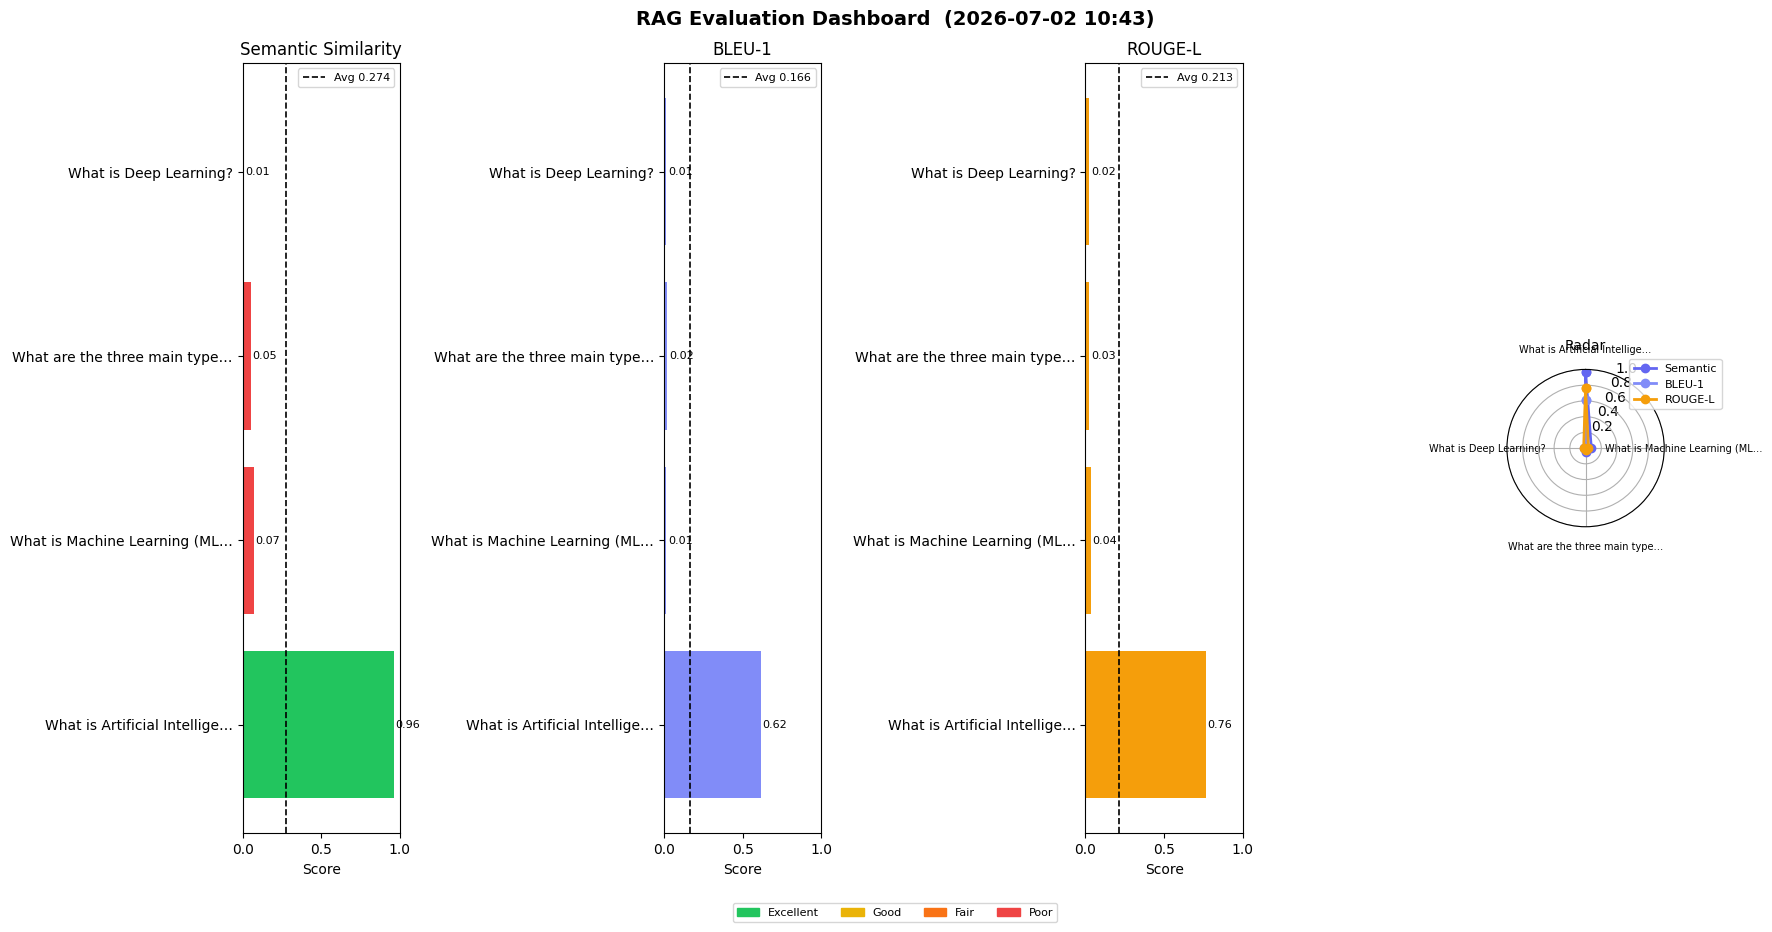


📜 Eval history (1 run(s)):
  2026-07-02 10:43  sem=0.274  bleu=0.166  rouge=0.213  Poor
HTML report → /content/eval_report.html


CSV → /content/eval_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Cell 10: Evaluation — ROUGE-L + BLEU-1 + Semantic + Radar Chart
import json as _json, numpy as np, csv, datetime, math, pathlib, base64
import nltk, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from IPython.display import display, HTML
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

NUM_EVAL_QUESTIONS = 4

# ── Auto-generate eval set ────────────────────────────────────────
def _auto_generate_eval_set(n: int = NUM_EVAL_QUESTIONS) -> list[dict]:
    _require_documents()
    all_docs = collection.get(include=['documents'])['documents']
    sampled  = all_docs[::max(1, math.ceil(len(all_docs)/20))][:20]
    prompt = (
        f'Generate exactly {n} question-answer pairs from the content below.\n'
        'Rules: answerable ONLY from content; each answer is one sentence.\n'
        'Return ONLY a JSON array, no preamble, no markdown fences.\n'
        'Format: [{"question": "...", "expected": "..."}]\n\n'
        f'CONTENT:\n{chr(10).join(sampled)}'
    )
    raw = call_gemini(prompt, stream=False)
    raw = _strip_code_fence(raw)
    try:
        pairs = _json.loads(raw)
        if isinstance(pairs, list) and pairs:
            print(f'Auto-generated {len(pairs)} eval question(s).')
            return pairs
    except Exception as e:
        print(f'JSON parse failed ({e}) — using fallback.')
    return []

FALLBACK_EVAL_SET = [{
    'question': 'What is the main topic of this document?',
    'expected': 'The document covers the main topic described in its introduction.',
}]

print('Generating eval questions...')
eval_set = _auto_generate_eval_set(NUM_EVAL_QUESTIONS) or FALLBACK_EVAL_SET
for i, item in enumerate(eval_set):
    print(f'  Q{i+1}: {item["question"]}')

# ── Scoring helpers ───────────────────────────────────────────────
_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def semantic_similarity(a: str, b: str) -> float:
    v = embedder.encode([a, b])
    return float(np.dot(v[0], v[1]) / (np.linalg.norm(v[0]) * np.linalg.norm(v[1])))

def bleu1(ref: str, hyp: str) -> float:
    r = nltk.word_tokenize(ref.lower())
    h = nltk.word_tokenize(hyp.lower())
    return sentence_bleu([r], h, weights=(1,0,0,0),
                         smoothing_function=SmoothingFunction().method1)

def rouge_l(ref: str, hyp: str) -> float:
    return _rouge.score(ref, hyp)['rougeL'].fmeasure

def score_label(s: float) -> str:
    if s >= 0.90: return 'Excellent'
    if s >= 0.80: return 'Good'
    if s >= 0.70: return 'Fair'
    return 'Poor'

GRADE_COLOR = {'Excellent':'#22c55e','Good':'#eab308','Fair':'#f97316','Poor':'#ef4444'}

# ── Run evaluation ────────────────────────────────────────────────
rows: list[dict] = []
print('\nRunning evaluation...')
for item in eval_set:
    pred = ask(item['question'], show_sources=False, stream=False)
    sem  = semantic_similarity(pred, item['expected'])
    bl   = bleu1(item['expected'], pred)
    rl   = rouge_l(item['expected'], pred)
    rows.append({
        'question': item['question'], 'expected': item['expected'],
        'predicted': pred,
        'semantic': round(sem, 4), 'bleu1': round(bl, 4),
        'rouge_l':  round(rl,  4), 'label': score_label(sem),
    })
    print(f'  ✓ sem={sem:.3f}  bleu={bl:.3f}  rouge-L={rl:.3f}  | {item["question"][:55]}')

avg_sem   = float(np.mean([r['semantic'] for r in rows]))
avg_bleu  = float(np.mean([r['bleu1']    for r in rows]))
avg_rouge = float(np.mean([r['rouge_l']  for r in rows]))
run_ts    = datetime.datetime.now().strftime('%Y-%m-%d %H:%M')

# ── Charts ────────────────────────────────────────────────────────
q_short  = [r['question'][:28]+'…' if len(r['question'])>28 else r['question'] for r in rows]
sem_vals = [r['semantic'] for r in rows]
bl_vals  = [r['bleu1']    for r in rows]
rl_vals  = [r['rouge_l']  for r in rows]
colors   = [GRADE_COLOR[r['label']] for r in rows]

fig = plt.figure(figsize=(18, 9))
fig.suptitle(f'RAG Evaluation Dashboard  ({run_ts})', fontsize=14, fontweight='bold')

for ax_idx, (vals, title, avg, color) in enumerate([
    (sem_vals, 'Semantic Similarity', avg_sem,   '#6366f1'),
    (bl_vals,  'BLEU-1',             avg_bleu,  '#818cf8'),
    (rl_vals,  'ROUGE-L',            avg_rouge, '#f59e0b'),
], start=1):
    ax = fig.add_subplot(1, 4, ax_idx)
    bars = ax.barh(q_short, vals, color=colors if ax_idx==1 else color)
    ax.set_xlim(0, 1)
    ax.axvline(avg, color='black', linestyle='--', linewidth=1.2, label=f'Avg {avg:.3f}')
    ax.set_title(title); ax.set_xlabel('Score'); ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=8)

# Radar
ax4 = fig.add_subplot(1, 4, 4, polar=True)
N = len(q_short)
angles = [n/N*2*math.pi for n in range(N)] + [0]
for vals, clr, lbl in [(sem_vals,'#6366f1','Semantic'),(bl_vals,'#818cf8','BLEU-1'),(rl_vals,'#f59e0b','ROUGE-L')]:
    v = vals + vals[:1]
    ax4.plot(angles, v, 'o-', linewidth=2, color=clr, label=lbl)
    ax4.fill(angles, v, alpha=0.1, color=clr)
ax4.set_theta_offset(math.pi/2); ax4.set_theta_direction(-1)
ax4.set_thetagrids([a*180/math.pi for a in angles[:-1]], q_short, fontsize=7)
ax4.set_ylim(0,1); ax4.set_title('Radar', fontsize=10, pad=14)
ax4.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

fig.legend(handles=[mpatches.Patch(color=c,label=l) for l,c in GRADE_COLOR.items()],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5,-0.04), fontsize=8)
plt.tight_layout()
chart_path = '/content/eval_chart.png'
plt.savefig(chart_path, dpi=140, bbox_inches='tight')
plt.show()

# ── Eval history ──────────────────────────────────────────────────
hist_path = pathlib.Path('/content/eval_history.json')
eval_hist = _json.loads(hist_path.read_text()) if hist_path.exists() else []
eval_hist.append({'run':run_ts,'avg_sem':round(avg_sem,4),'avg_bleu':round(avg_bleu,4),
                  'avg_rouge':round(avg_rouge,4),'grade':score_label(avg_sem),'n':len(rows)})
hist_path.write_text(_json.dumps(eval_hist, indent=2))
print(f'\n📜 Eval history ({len(eval_hist)} run(s)):')
for h in eval_hist:
    print(f"  {h['run']}  sem={h['avg_sem']:.3f}  bleu={h['avg_bleu']:.3f}  rouge={h['avg_rouge']:.3f}  {h['grade']}")

# ── HTML report ───────────────────────────────────────────────────
def _badge(label):
    c = GRADE_COLOR[label]
    return f'<span style="background:{c};color:#fff;padding:2px 8px;border-radius:4px;font-size:.8em;font-weight:bold">{label}</span>'

rows_html = ''.join(
    f"<details style='margin:10px 0;border:1px solid #e2e8f0;border-radius:8px'>"
    f"<summary style='padding:12px 16px;cursor:pointer;background:#f8fafc;border-radius:8px;font-weight:600'>"
    f"Q{i+1}: {r['question']} &nbsp; Sem:<b>{r['semantic']}</b> {_badge(r['label'])} "
    f"BLEU:<b>{r['bleu1']}</b> ROUGE-L:<b>{r['rouge_l']}</b></summary>"
    f"<div style='padding:14px 18px'><p><b>Expected:</b> {r['expected']}</p>"
    f"<p><b>Got:</b> {r['predicted']}</p></div></details>"
    for i, r in enumerate(rows)
)
hist_rows = ''.join(
    f"<tr><td>{h['run']}</td><td>{h['avg_sem']:.3f}</td><td>{h['avg_bleu']:.3f}</td>"
    f"<td>{h['avg_rouge']:.3f}</td><td>{h['n']}</td><td>{_badge(h['grade'])}</td></tr>"
    for h in eval_hist
)
chart_b64 = base64.b64encode(pathlib.Path(chart_path).read_bytes()).decode()
html = f"""<!DOCTYPE html><html lang='en'><head><meta charset='UTF-8'>
<title>RAG Eval {run_ts}</title><style>
body{{font-family:system-ui,sans-serif;max-width:1000px;margin:40px auto;padding:0 20px;color:#1e293b}}
h1{{border-bottom:3px solid #6366f1;padding-bottom:8px}}
.grid{{display:grid;grid-template-columns:repeat(5,1fr);gap:14px;margin:24px 0}}
.card{{background:#f8fafc;border:1px solid #e2e8f0;border-radius:10px;padding:16px;text-align:center}}
.card .v{{font-size:1.9em;font-weight:800;color:#6366f1}}
.card .m{{font-size:.85em;color:#64748b;margin-top:4px}}
table{{width:100%;border-collapse:collapse;margin-top:12px}}
th,td{{padding:10px 12px;text-align:left;border-bottom:1px solid #e2e8f0}}
th{{background:#f1f5f9;font-weight:600}}
</style></head><body>
<h1>RAG Evaluation Report</h1>
<p style='color:#64748b'>Generated: {run_ts} | {len(rows)} questions</p>
<div class='grid'>
  <div class='card'><div class='v'>{avg_sem:.3f}</div><div class='m'>Avg Semantic</div></div>
  <div class='card'><div class='v'>{avg_bleu:.3f}</div><div class='m'>Avg BLEU-1</div></div>
  <div class='card'><div class='v'>{avg_rouge:.3f}</div><div class='m'>Avg ROUGE-L</div></div>
  <div class='card'><div class='v'>{len(rows)}</div><div class='m'>Questions</div></div>
  <div class='card'><div class='v' style='font-size:1.3em'>{score_label(avg_sem)}</div><div class='m'>Grade</div></div>
</div>
<h2>Charts</h2><img src='data:image/png;base64,{chart_b64}' style='width:100%;border-radius:8px'>
<h2>Per-Question Results</h2>{rows_html}
<h2>Run History</h2><table>
<tr><th>Run</th><th>Semantic</th><th>BLEU-1</th><th>ROUGE-L</th><th>Questions</th><th>Grade</th></tr>
{hist_rows}</table></body></html>"""

html_path = '/content/eval_report.html'
with open(html_path, 'w', encoding='utf-8') as f: f.write(html)
print(f'HTML report → {html_path}')

# Inline summary
display(HTML(f"""
<div style='display:flex;gap:14px;flex-wrap:wrap;margin:16px 0'>
  <div style='background:#f0f9ff;border:1px solid #bae6fd;border-radius:8px;padding:16px 22px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#0ea5e9'>{avg_sem:.3f}</div>
    <div style='color:#64748b;font-size:.85em'>Avg Semantic</div></div>
  <div style='background:#faf5ff;border:1px solid #e9d5ff;border-radius:8px;padding:16px 22px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#a855f7'>{avg_bleu:.3f}</div>
    <div style='color:#64748b;font-size:.85em'>Avg BLEU-1</div></div>
  <div style='background:#fffbeb;border:1px solid #fde68a;border-radius:8px;padding:16px 22px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#d97706'>{avg_rouge:.3f}</div>
    <div style='color:#64748b;font-size:.85em'>Avg ROUGE-L</div></div>
  <div style='background:#f0fdf4;border:1px solid #bbf7d0;border-radius:8px;padding:16px 22px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#22c55e'>{score_label(avg_sem)}</div>
    <div style='color:#64748b;font-size:.85em'>Grade</div></div>
</div>"""))

# CSV
csv_path = '/content/eval_results.csv'
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=['question','expected','predicted','semantic','bleu1','rouge_l','label'])
    w.writeheader(); w.writerows(rows)
print(f'CSV → {csv_path}')

try:
    from google.colab import files as _cf
    for p in [csv_path, html_path, chart_path]: _cf.download(p)
except Exception: pass